## Exercise in Photogrammetry I
## **Ex.5 : Local Operators**
### Hand out: xx.xx.xxxx
### Submission: xx.xx.xxxx 
### Points: 25

## A. Image convolutions

In this task you will learn how to apply local operators in the form of image convolutions.
A convolution *g* of a symmetric 3x3 Kernel *w* with an image *f* is defined as:

$g(i,j)= \sum_{k,l=-1}^1 f(i-k,j-l)\cdot w(k,l)$

In this exercise we will brake down the convolution in multiple steps. This allows for a more intuitive and efficient way by bypassing alot of the indexing and working with matrices.

**Pseudo Code - imageConv(f,w):**
1. *w_s*:= row and columnwise flipped kernel *w* .
2. for each pixel *f(i,j)*:
    1. *N_ij* = N8 neighborhood of the pixel *f(i,j)* (3x3 matrix).
    2. *p = w_s * N_ij*, * denotes the elementwise multiplication
    3. *g(i,j)*= sum(*p*).

**Tasks:**
1. compute the convolution for the following image *f* and kernel *w* by **hand**. Follow the provided pseudo code and write down the results of each step. Scan/ take a photo from the sheet(s) and visualize it. Compute the convolution just for the 2 pixels in the middle (*g(1,1), g(2,1)*). (7 points)

In [23]:
# import all required modules
import skimage.io
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
%matplotlib inline

Test Image:
[[0 1 0 2]
 [0 1 3 1]
 [1 0 0 2]]
Test Kernel:
[[1 2 3]
 [4 5 6]
 [7 8 9]]


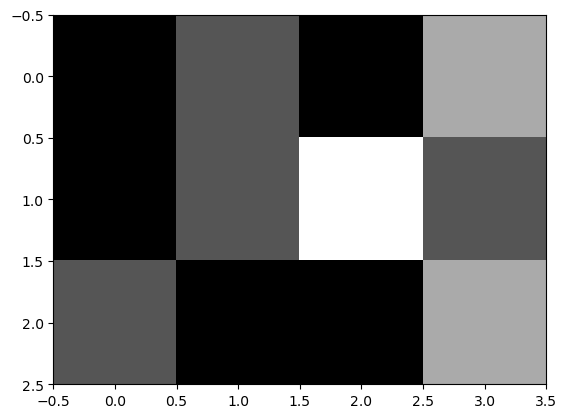

In [11]:
# Image f and Kernel w for A1
f = np.array([[0,1,0,2],[0,1,3,1],[1,0,0,2]])
print('Test Image:')
print(f)

w = np.array([[1,2,3],[4,5,6],[7,8,9]])
print('Test Kernel:')
print(w)
plt.figure()
plt.imshow(f, cmap='gray')
plt.show()

Output Image:
[[ 0  1  0  2]
 [ 0 28  3  1]
 [ 1 35  0  2]]


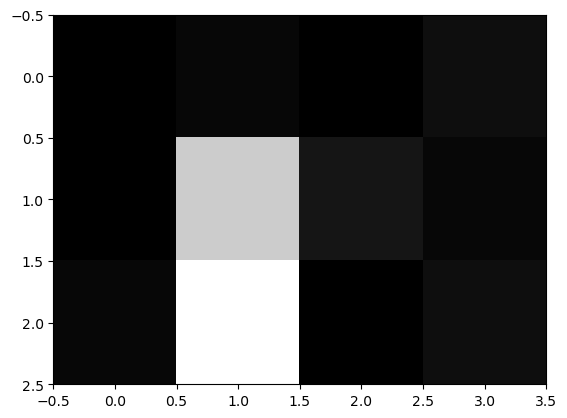

In [7]:
# Plot the result sheet with the answers of A1 here:

# Image f and Kernel w for A1
f = np.array([[0,1,0,2],[0,28,3,1],[1,35,0,2]])
print('Output Image:')
print(f)

plt.figure()
plt.imshow(f, cmap='gray')
plt.show()

### **Tasks:**
2. write a function ```imageConv(f,w)``` which implements the pseudo code and returns the image after applying the convolution. Compute the convolution for all pixels where the neighborhood is well defined. The border can be set to zero (also called zero padding). (8  points)
3. load the image ```images/house-downsampled.png``` as a grayscale image and visualize it. (1 point)
4. compute the convolution of the image with the following **3x3** kernels and visualize the results. Use your implementation of ```imageConv(f,w)``` for applying the convolution:
    1. Box filter (1 point)
    2. Binominal filter (1 point)
    3. Sobel Operator. Compute the absolute gradient (2 points)
5. compute the convolution of the image with the following **5x5** kernels and visualize the results. Use the function ```ndimage.convolve(...)``` from scipy for applying the convolution. **Hint:** For more information about the function press ```shift + tab``` or look into the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html#scipy.ndimage.convolve).
    1. Box filter (1 point)
    2. Binominal filter (1 point)
6. evaluate the results of the tasks 4 and 5. (3 point)

In [21]:
def imageConv(f,w):

    f_w = np.flip(w,0) # row wise flipped kernel
    f_w = np.flip(f_w,1) # column wise flipped kernel

    output_image = np.zeros(np.shape(f)) # initializa the output image

    for row in range(np.shape(f)[0]): # loop through each row
        for col in range(np.shape(f)[1]): # loop through each column
            sum = 0 # store sum from the neighbors for current pixel location
            sum += (f[row,col]*f_w[1,1]) # perform multiplication and add to sum using the center pixel of the kernel
            if row-1 >= 0: # check the neighbor above
                sum += (f[row-1,col]*f_w[0,1]) # perform multiplication and add to sum
            if row+1 < np.shape(f)[0]: # check the neighbor below
                sum += (f[row+1,col]*f_w[2,1]) # perform multiplication and add to sum
            if col-1 >= 0: # check the left neighbor
                sum += (f[row,col-1]*f_w[1,0]) # perform multiplication and add to sum
            if col+1 < np.shape(f)[1]: # check right neighbor
                sum += (f[row,col+1]*f_w[1,2]) # perform multiplication and add to sum
            if row-1 >= 0 and col-1 >= 0: # check top left diagonal neighbor
                sum += (f[row-1,col-1]*f_w[0,0]) # perform multiplication and add to sum
            if row-1 >= 0 and col+1 < np.shape(f)[1]: # check top right diagonal neighbor
                sum += (f[row-1,col+1]*f_w[0,2]) # perform multiplication and add to sum
            if row+1 < np.shape(f)[0] and col-1 >= 0: # check bottom left diagonal neighbor
                sum += (f[row+1,col-1]*f_w[2,0]) # perform multiplication and add to sum
            if row+1 < np.shape(f)[0] and col+1 < np.shape(f)[1]: # check bottom right diagonal neighbor
                sum += (f[row+1,col+1]*f_w[2,2]) # perform multiplication and add to sum

            output_image[row,col] = sum

    return output_image
            

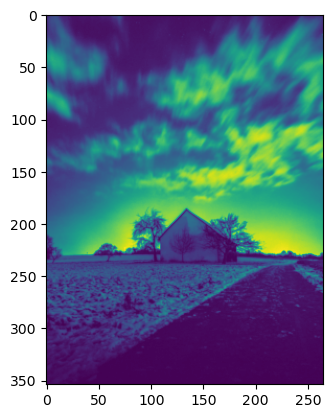

In [27]:
img = cv2.imread('images/house-downsampled.png', cv2.IMREAD_GRAYSCALE)
plt.figure()
plt.imshow(img)
plt.show()

In [31]:
# Applying 3x3 Box Filter

In [36]:
k = np.array([[0.111,0.111,0.111],[0.111,0.111,0.111],[0.111,0.111,0.111]])

In [38]:
img_bf = imageConv(img,k)

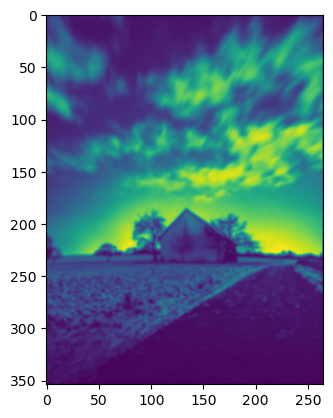

In [40]:
plt.figure()
plt.imshow(img_bf)
plt.show()

In [42]:
# Applying 3x3 Binomial Filter

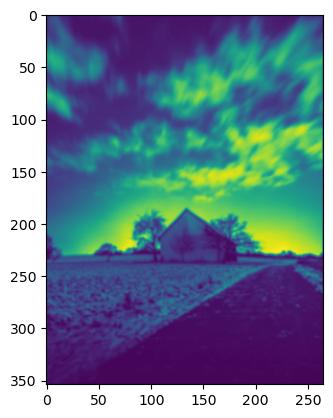

In [44]:
k = np.array([[1,2,1],[2,4,2],[1,2,1]])/16
img_bf = imageConv(img,k)
plt.figure()
plt.imshow(img_bf)
plt.show()

In [48]:
# Applying Sobel Operator

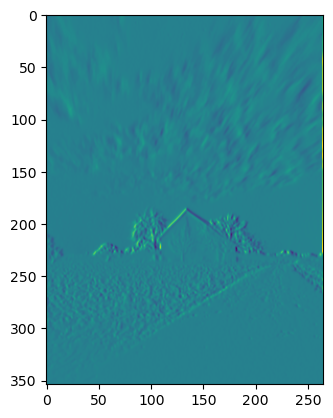

In [52]:
# computing horizontal gradient
k = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
img_gx = imageConv(img,k)
plt.figure()
plt.imshow(img_gx)
plt.show()

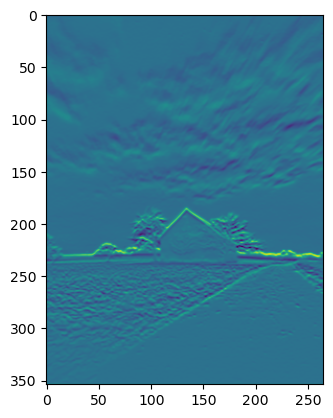

In [54]:
# computing vertical gradient
k = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
img_gy = imageConv(img,k)
plt.figure()
plt.imshow(img_gy)
plt.show()

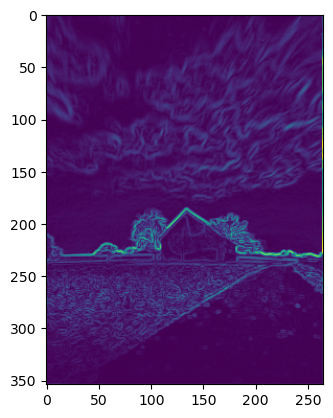

In [60]:
# computing the absolute gradient
G = ((img_gx)**2 + (img_gy)**2)**(1/2)
plt.figure()
plt.imshow(G)
plt.show()

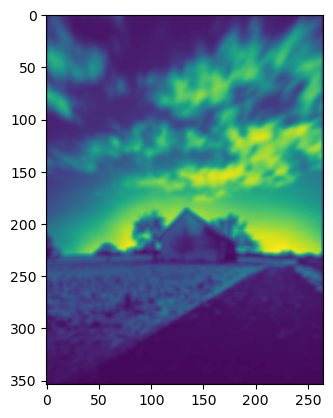

In [66]:
# 5x5 box filter
k = np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])/25
img_bf = ndimage.convolve(img, k, mode='constant', cval=0.0)
plt.figure()
plt.imshow(img_bf)
plt.show()

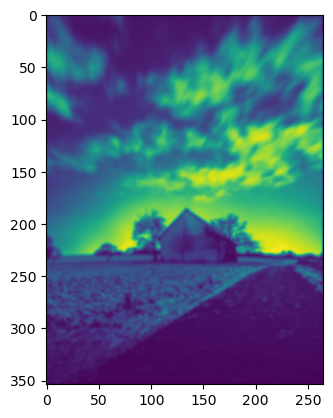

In [72]:
# 5x5 binomial filter
k = np.array([[1,4,6,4,1],[4,16,24,16,4],[6,24,36,24,6],[4,16,24,16,4],[1,4,6,4,1]])/256
img_bf = ndimage.convolve(img, k, mode='constant', cval=0.0)
plt.figure()
plt.imshow(img_bf)
plt.show()

In [ ]:
# For box filter, by increasing the kernel size, the image gets more smoothed.
# for binomial filter, increasing the kernel size, the result gets smoother, more natural blur than a box filter.
# for sobel operator, it first computes edged in horizontal direction, then in vertical direction, absolute gradient combines both edge images essentially producing a map of the edges and boundaries.
